# Figure assembly notebook

This notebook assembles manuscript-ready figures from completed evaluation outputs.
It uses shared plotting helpers, and saves exports into the configured `outputs.directory`.

## Required inputs
- `config.yaml` to resolve the evaluation output root.
- Parquet outputs generated by the synthetic, sparsification, stability, and Boston workflows.

## Generated outputs
- Inline previews for quick review.
- Publication-ready exports under `results/figures/` (resolved from `config.yaml`).


## Workflow

Run the notebook from top to bottom after refreshing the evaluation results. Each
section loads only the tables it needs and ends by previewing one figure:

1. Sparsification compatibility surfaces (`Fig1`)
2. Synthetic performance summaries (`Fig2`, `Fig3`)
3. Temporal stability diagnostics (`Fig4`)
4. Boston cluster descriptives (`Fig5`)


In [55]:
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import seaborn as sns

from config import load_config, outputs_root, project_root
from plotting import (
    PLOS_WIDTHS_CM,
    add_panel_labels,
    cm_to_inch,
    save_plos_figure,
    set_plos_theme,
)

In [56]:
PROJECT_ROOT = project_root()
CONFIG = load_config()
RESULTS_ROOT = outputs_root(CONFIG)
FIGURE_OUTPUT_DIR = RESULTS_ROOT / "figures"
SAVE_FIGURES = True


def read_result_table(*parts: str) -> pd.DataFrame:
    return pd.read_parquet(RESULTS_ROOT.joinpath(*parts))


def export_figure(fig: plt.Figure, stem: str, **kwargs) -> dict[str, Path]:
    if not SAVE_FIGURES:
        return {}
    return save_plos_figure(fig, stem, outdir=FIGURE_OUTPUT_DIR, **kwargs)


set_plos_theme()

print(f"Project root: {PROJECT_ROOT}")
print(f"Results root: {RESULTS_ROOT}")
print(f"Figure output directory: {FIGURE_OUTPUT_DIR}")
print(f"Save figures: {SAVE_FIGURES}")


Project root: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation
Results root: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results
Figure output directory: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures
Save figures: True


## Figure 1 · Compatibility surfaces

In [3]:
surfaces = read_result_table("sparsification", "score_surfaces.parquet")

SURFACE_PANELS = ("compatibility_deterministic", "compatibility_stochastic")


def surface_matrix(surface_frame: pd.DataFrame, score: str) -> pd.DataFrame:
    """Pivot a long surface table into a days-by-SNP matrix."""
    return (
        surface_frame.pivot(index="days", columns="snp", values=score)
        .sort_index()
        .sort_index(axis=1)
    )


def add_surface_panel(
    ax: plt.Axes,
    surface_frame: pd.DataFrame,
    score: str,
):
    pivot = surface_matrix(surface_frame, score)
    x_values = pivot.columns.to_numpy(dtype=float)
    y_values = pivot.index.to_numpy(dtype=float)
    z_values = pivot.to_numpy(dtype=float)

    filled = ax.contourf(
        x_values,
        y_values,
        z_values,
        levels=np.linspace(0.0, 1.0, 11),
        cmap="mako",
        antialiased=True,
    )
    ax.xaxis.set_major_locator(MultipleLocator(3))
    ax.yaxis.set_major_locator(MultipleLocator(3))
    return filled

Saved PDF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig2.pdf
Saved TIFF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig2.tif


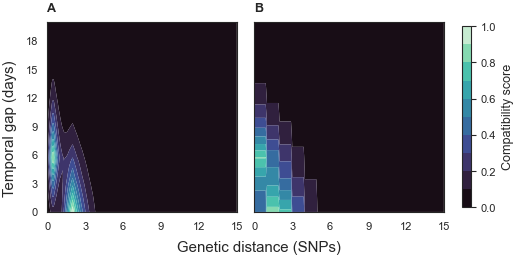

In [4]:
fig1, axes1 = plt.subplots(
    1,
    2,
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]) * 0.5,
    ),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    gridspec_kw={"hspace": 0.1},
)
axes1 = np.atleast_1d(axes1).flatten()

filled = None
for ax, score in zip(axes1, SURFACE_PANELS):
    filled = add_surface_panel(ax, surfaces, score)

if filled is None:
    raise RuntimeError("No surface panels were drawn.")

colorbar = fig1.colorbar(
    filled,
    ax=axes1,
    location="right",
    shrink=0.95,
    pad=0.03,
)
colorbar.set_label("Compatibility score")

fig1.supxlabel("Genetic distance (SNPs)")
fig1.supylabel("Temporal gap (days)")
add_panel_labels(list(axes1))
export_figure(fig1, "Fig2")
plt.show()

## Figures 2–3 · Synthetic sensitivity results

In [61]:
results = read_result_table("synthetic", "results.parquet").copy()

SCENARIO_LABELS = {
    "baseline": "Baseline",
    "incubation_mean_0.75": "Inc mean ↓25%",
    "incubation_mean_1.25": "Inc mean ↑25%",
    "incubation_cv_0.75": "Inc CV ↓25%",
    "incubation_cv_1.25": "Inc CV ↑25%",
    "testing_delay_mean_0.75": "Test mean ↓25%",
    "testing_delay_mean_1.25": "Test mean ↑25%",
    "testing_delay_cv_0.75": "Test CV ↓25%",
    "testing_delay_cv_1.25": "Test CV ↑25%",
    "substitution_rate_0.75": "Clock rate ↓25%",
    "substitution_rate_1.25": "Clock rate ↑25%",
    "relaxation_0.00": "Strict clock",
    "relaxation_1.25": "Relaxation ↑25%",
}
SCENARIO_ORDER = [
    "incubation_mean_0.75",
    "incubation_mean_1.25",
    "incubation_cv_0.75",
    "incubation_cv_1.25",
    "testing_delay_mean_0.75",
    "testing_delay_mean_1.25",
    "testing_delay_cv_0.75",
    "testing_delay_cv_1.25",
    "substitution_rate_0.75",
    "substitution_rate_1.25",
    "relaxation_0.00",
    "relaxation_1.25",
]

CONDITION_LABELS = {
    "matched": "Matched",
    "generation_varied_inference_fixed": "Mismatched",
}
CONDITION_ORDER = list(CONDITION_LABELS.values())
CONDITION_COLORS = {
    "Matched": "#185FA5",
    "Mismatched": "#993C1D",
}

results["condition"] = (
    results["condition"].map(CONDITION_LABELS).fillna(results["condition"])
)

METRIC_PANELS = [
    ("ap", "Average precision"),
    ("best_f1", "Best F1 score"),
    ("mean_stability", "Partition stability (mean)"),
    ("std_stability", "Partition stability (SD)"),
]
LOSS_PANELS = [
    ("ap_loss", "Matched"),
    ("ap_loss", "Mismatched"),
    ("f1_loss", "Matched"),
    ("f1_loss", "Mismatched"),
]

MODEL_ORDER = list(results["model"].drop_duplicates())


def plot_metric_panel(
    ax: plt.Axes,
    df: pd.DataFrame,
    metric: str,
    title: str,
) -> None:
    sns.pointplot(
        data=df,
        x="model",
        y=metric,
        hue="condition",
        palette=CONDITION_COLORS,
        order=MODEL_ORDER,
        hue_order=CONDITION_ORDER,
        dodge=True,
        errorbar=("ci", 95),
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel(title)
    ax.set_ylim(0, 1)

In [62]:
baseline = results.loc[(results["scenario"] == "baseline")
                       & (results["condition"] == "Matched")]

for data in baseline.to_dict(orient="records"):
    print(
        f"\t{data["model"]}: "
        f"AP={data["ap"]:.3f}, "
        f"F1={data["best_f1"]:.3f}, "
        f"Mean={data["mean_stability"]:.3f} "
        f"SD={data["std_stability"]:.3f} "
    )

	EDD: AP=0.300, F1=0.556, Mean=0.871 SD=0.077 
	EDS: AP=0.090, F1=0.476, Mean=0.834 SD=0.090 
	ESD: AP=0.469, F1=0.601, Mean=0.851 SD=0.073 
	ESS: AP=0.190, F1=0.534, Mean=0.830 SD=0.079 
	LD: AP=0.568, F1=0.688, Mean=0.895 SD=0.044 
	LS: AP=0.275, F1=0.570, Mean=0.927 SD=0.094 


Saved PDF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig3.pdf
Saved TIFF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig3.tif


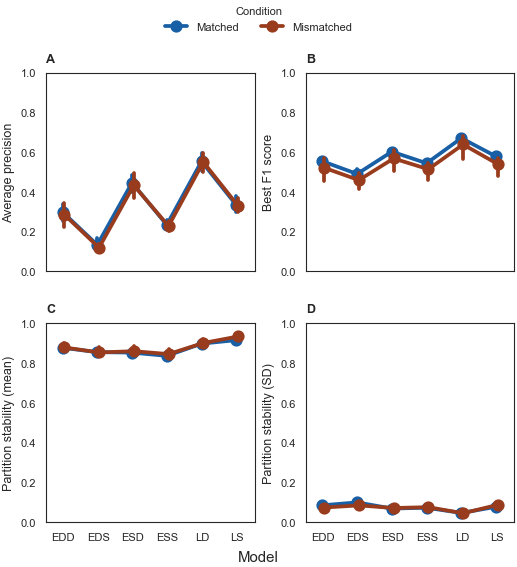

In [63]:
fig2, axes2 = plt.subplots(
    2,
    2,
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
    ),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"hspace": 0.1},
)
axes2 = axes2.flatten()

for ax, (metric, title) in zip(axes2, METRIC_PANELS):
    plot_metric_panel(ax, results, metric=metric, title=title)

handles, labels = axes2[0].get_legend_handles_labels()
for ax in axes2:
    if ax.legend_ is not None:
        ax.legend_.remove()

fig2.legend(
    handles,
    labels,
    title="Condition",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=2,
)
fig2.supxlabel("Model")
add_panel_labels(list(axes2), size="medium")
export_figure(fig2, "Fig3")
plt.show()


In [72]:
data = results.loc[(results["scenario"] != "baseline") & (results["condition"] == "Mismatched")]

(data[["model", "scenario", "f1_loss"]]
.pivot_table(index="scenario", columns="model", values="f1_loss")
.reindex(index=SCENARIO_ORDER, columns=MODEL_ORDER).reset_index()
 )

model,scenario,EDD,EDS,ESD,ESS,LD,LS
0,incubation_mean_0.75,-0.202881,-0.116345,-0.074607,-0.043842,-0.085365,-0.011088
1,incubation_mean_1.25,0.112084,0.106996,0.023511,0.043373,-0.011461,-0.024745
2,incubation_cv_0.75,0.019877,0.013886,0.051775,0.027468,0.005562,0.018886
3,incubation_cv_1.25,-0.619854,-0.557423,-0.629384,-0.567429,-0.656177,-0.646646
4,testing_delay_mean_0.75,-0.031592,-0.011589,-0.012301,0.001845,-0.031468,-0.003447
5,testing_delay_mean_1.25,0.038777,0.044586,0.013470,0.017286,-0.000396,-0.007434
6,testing_delay_cv_0.75,-0.018703,0.022663,-0.005026,0.016892,-0.019063,0.012855
7,testing_delay_cv_1.25,-0.012875,-0.008104,-0.011626,-0.012799,-0.025940,-0.024218
8,substitution_rate_0.75,-0.271910,-0.132461,-0.152679,-0.061328,-0.106409,-0.019591
9,substitution_rate_1.25,0.145274,0.140644,0.055469,0.078535,-0.019111,-0.014800


**EDS consistently gains the most from parameter changes.** The stochastic-input, deterministic-inference model shows the largest positive swings in almost every scenario — peaking dramatically at +2.53 for `incubation_cv ×1.25`. This suggests it is highly sensitive to distributional assumptions, gaining a lot when those match the data better but also risking large swings in the wrong direction.

**EDD and ESD degrade the most when parameters shift downward.** Both fully- or partially-deterministic models (EDD especially) take the worst hits under `substitution_rate ×0.75` (−0.51 and −0.41) and `incubation_mean ×0.75` (−0.42 and −0.30). Deterministic inference without stochastic inputs seems brittle to lower-than-baseline parameter values.

**Stochastic models (EDS, ESS, LS) almost universally stay positive or recover quickly.** For scenarios where EDD/ESD/LD are negative, the stochastic-input variants of the same inference family are either near zero or positive — compare `substitution_rate ×0.75`: EDD = −0.51, EDS = +0.20.

**`relaxation ×0.00` (complete absence of relaxation) benefits all models**, with EDS and EDD gaining the most (+0.70, +0.50). This implies the baseline already has some relaxation that actively hurts performance; removing it uniformly improves results.

**Testing delay parameters produce the most muted effects.** Both mean and CV perturbations of the testing delay yield smaller absolute changes across all models, suggesting the models are relatively robust to this parameter compared to incubation period or substitution rate.

**The substitution rate and incubation mean are the most consequential parameters overall** — they produce the largest negative swings (when decreased) and sizable positive swings (when increased), making them the primary drivers of model sensitivity.

## Figure 4 · Temporal stability across epidemic weeks

In [54]:
stability_frames = {
    "EDD": read_result_table("stability", "temporal_stability_EDD.parquet"),
    "EDS": read_result_table("stability", "temporal_stability_EDS.parquet"),
    "ESD": read_result_table("stability", "temporal_stability_ESD.parquet"),
    "ESS": read_result_table("stability", "temporal_stability_ESS.parquet"),
    "LD": read_result_table("stability", "temporal_stability_LD.parquet"),
    "LS": read_result_table("stability", "temporal_stability_LS.parquet"),
}
STABILITY_MARKERS = {
    "forward": "^",
    "backward": "*",
    "jaccard": "d",
}
STABILITY_COLORS = {
    "forward": "#0072B2",
    "backward": "#D55E00",
    "jaccard": "#CC79A7",
}
STABILITY_LABELS = {
    "forward": "Forward",
    "backward": "Backward",
    "jaccard": "Jaccard",
}


def plot_stability_panel(
    df: pd.DataFrame,
    ax: plt.Axes,
    model: str,
) -> None:
    for metric in ("forward", "backward", "jaccard"):
        sns.lineplot(
            data=df,
            x="t1",
            y=metric,
            color=STABILITY_COLORS[metric],
            marker=STABILITY_MARKERS[metric],
            ax=ax,
            label=STABILITY_LABELS[metric],
        )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_ylim(0, 1.05)
    ax.set_title(model, fontsize="small", fontweight="bold")

    # ax.text(
    #     0.98, 0, model, transform=ax.transAxes,
    #     ha="right",va="bottom")


Saved PDF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig5.pdf
Saved TIFF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig5.tif


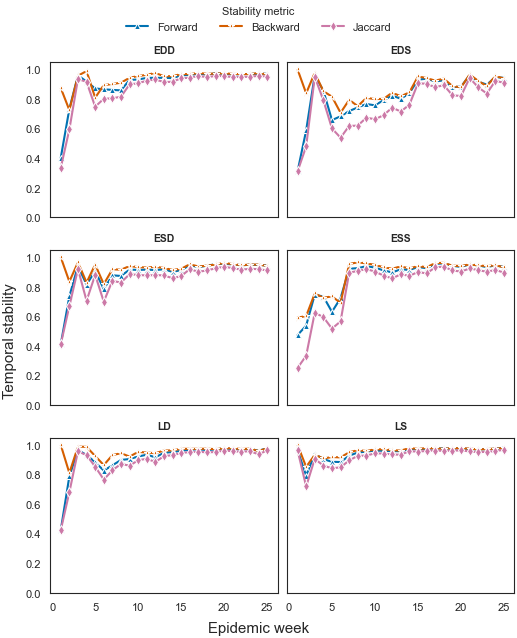

In [57]:
fig4, axes4 = plt.subplots(
    3,
    2,
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]) * 1.15,
    ),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    gridspec_kw={"hspace": 0.05},
)
axes4 = axes4.flatten()

for ax,  (m, frame) in zip(axes4, stability_frames.items()):
    plot_stability_panel(frame, ax, m)

handles, labels = axes4[0].get_legend_handles_labels()
for ax in axes4:
    if ax.legend_ is not None:
        ax.legend_.remove()

fig4.legend(
    handles,
    labels,
    title="Stability metric",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.075),
    ncol=3,
)
fig4.supylabel("Temporal stability")
fig4.supxlabel("Epidemic week")
# add_panel_labels(list(axes4))
export_figure(fig4, "Fig5")
plt.show()


In [12]:
stability_frames["EDD"][["forward", "backward", "jaccard"]].min()

forward     0.403061
backward    0.725342
jaccard     0.335177
dtype: float64

In [13]:
stability_frames["EDS"][["forward", "backward", "jaccard"]].min()

forward     0.311111
backward    0.707183
jaccard     0.311111
dtype: float64

In [14]:
stability_frames["ESD"][["forward", "backward", "jaccard"]].min()

forward     0.411765
backward    0.817525
jaccard     0.411765
dtype: float64

In [15]:
stability_frames["ESS"][["forward", "backward", "jaccard"]].min()

forward     0.473684
backward    0.591837
jaccard     0.251701
dtype: float64

In [16]:
stability_frames["LD"][["forward", "backward", "jaccard"]].min()

forward     0.424242
backward    0.810277
jaccard     0.424242
dtype: float64

In [17]:
stability_frames["LS"][["forward", "backward", "jaccard"]].min()

forward     0.792754
backward    0.851449
jaccard     0.719302
dtype: float64

## Figure 5 · Boston cluster composition

The final section pairs cluster-size frequencies with exposure composition across
focus clusters. It provides a compact descriptive summary for the empirical case study.


Saved PDF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig6.pdf
Saved TIFF: /Users/ydnkka/Desktop/Phd Project/projects/epilink/evaluation/results/figures/Fig6.tif


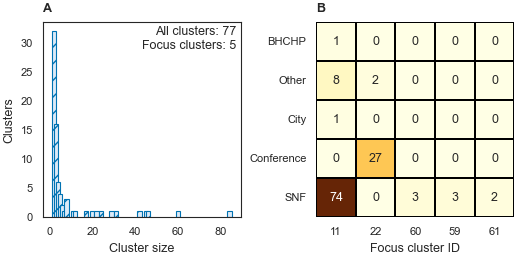

In [18]:
boston_comp = read_result_table("boston", "cluster_composition.parquet")
boston_sizes = read_result_table("boston", "cluster_sizes.parquet")

EXPOSURE_LABELS = {
    "count::BHCHP": "BHCHP",
    "count::Other": "Other",
    "count::City": "City",
    "count::Conference": "Conference",
    "count::SNF": "SNF",
}

available_columns = [column for column in EXPOSURE_LABELS if column in boston_comp.columns]
if not available_columns:
    raise ValueError("No configured exposure columns were found in the Boston results.")

exposure_counts = boston_comp[available_columns].copy().rename(columns=EXPOSURE_LABELS)
exposure_counts.index = boston_comp["cluster_id"].astype(int)
size_counts = boston_sizes["size"].value_counts().sort_index()

fig5, axes5 = plt.subplots(
    1,
    2,
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]) * 0.5,
    ),
    constrained_layout=True,
)
axes5 = np.atleast_1d(axes5).flatten()

bars = axes5[0].bar(
    size_counts.index,
    size_counts.values,
    color="#DDEAF7",
    edgecolor="#0072B2",
    linewidth=0.8,
    width=2,
)
for patch in bars:
    patch.set_hatch("//")

axes5[0].set(xlabel="Cluster size", ylabel="Clusters")
axes5[0].text(
    0.98,
    0.98,
    (
        f"All clusters: {len(boston_sizes)}\n"
        f"Focus clusters: {int(boston_sizes['is_focus_cluster'].sum())}"
    ),
    transform=axes5[0].transAxes,
    ha="right",
    va="top",
)

vmax = float(np.nanmax(exposure_counts.to_numpy(dtype=float)))
sns.heatmap(
    exposure_counts.T,
    vmin=0,
    vmax=max(1.0, vmax),
    cmap="YlOrBr",
    annot=True,
    fmt=".0f",
    linewidths=0.01,
    linecolor="black",
    cbar=False,
    ax=axes5[1],
)
axes5[1].tick_params(axis="y", rotation=0)
axes5[1].set_xlabel("Focus cluster ID")
axes5[1].set_ylabel("")

add_panel_labels(list(axes5))
export_figure(fig5, "Fig6")
plt.show()


In [19]:
boston_sizes["size"].describe()

count    77.000000
mean      8.337662
std      14.420937
min       2.000000
25%       2.000000
50%       3.000000
75%       5.000000
max      84.000000
Name: size, dtype: float64

## Notes

- Set `SAVE_FIGURES = False` to preview plots without writing files.
- Re-run the data-loading cells after refreshing any upstream parquet outputs.
- Exports are grouped under `results/figures/`.
